In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset loaded successfully!")

Saving seasonal_agriculture_performance_dataset (2).csv to seasonal_agriculture_performance_dataset (2).csv
Dataset loaded successfully!


In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 4000
Number of Columns: 28


In [ ]:
display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [ ]:
missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

display(missing_table[missing_table["Missing Values"] > 0])

,Missing Values,Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate records:", duplicates)

Duplicate records: 0


In [ ]:
# Fill missing numerical values with median
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicate rows
df = df.drop_duplicates()

print("Data cleaning completed!")
print("Remaining missing values:", df.isnull().sum().sum())
print("Dataset shape:", df.shape)

Data cleaning completed!
Remaining missing values: 0
Dataset shape: (4000, 28)


In [ ]:
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print("\n", col)
    print(df[col].value_counts())


 State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

 District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

 Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

 Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

 Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


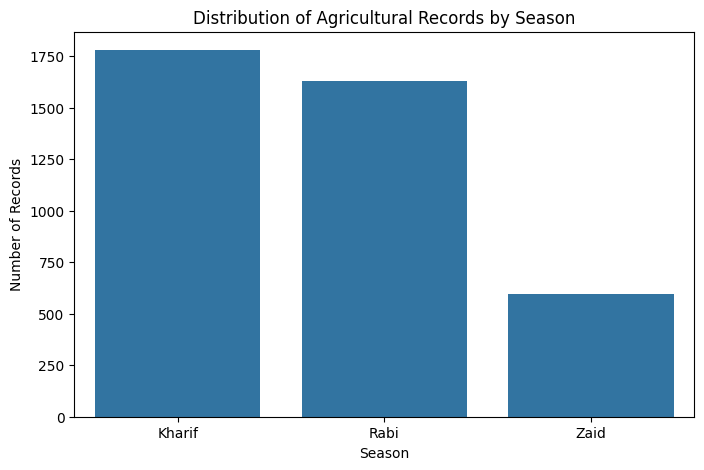

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Season")

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.show()

In [ ]:
season_summary = df.groupby("Season").agg({
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Humidity_pct": "mean",
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Total_Cost_INR": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
}).round(2)

display(season_summary)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Yield_Tonnes_Ha,Production_Tonnes,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,,,,
Kharif,849.20,28.45,71.81,5.63,46.31,531804.41,710719.06,178914.65,6102.20,5.89
Rabi,437.62,23.49,57.89,5.04,41.49,513836.58,601526.05,87689.47,5846.99,5.19
Zaid,304.65,31.04,52.01,4.64,38.89,543976.73,519171.90,-24804.82,6419.89,4.41


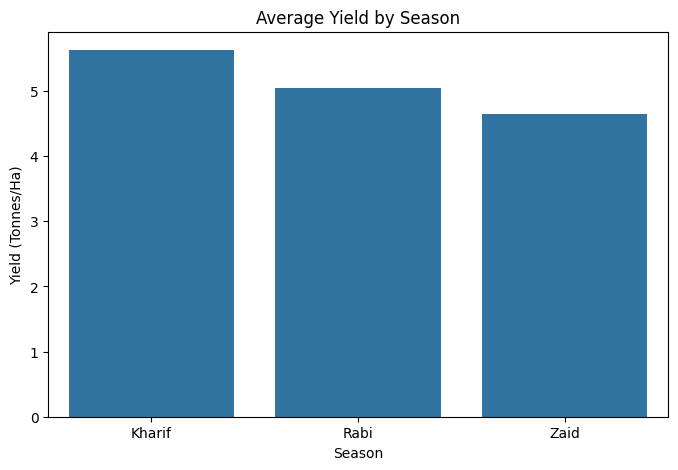

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

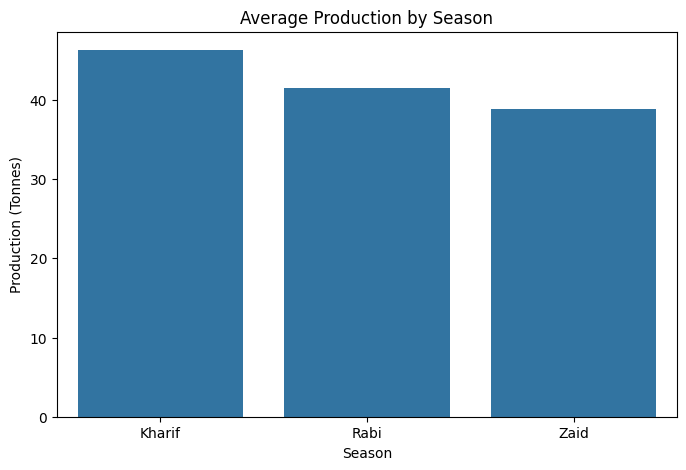

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Production_Tonnes",
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")

plt.show()

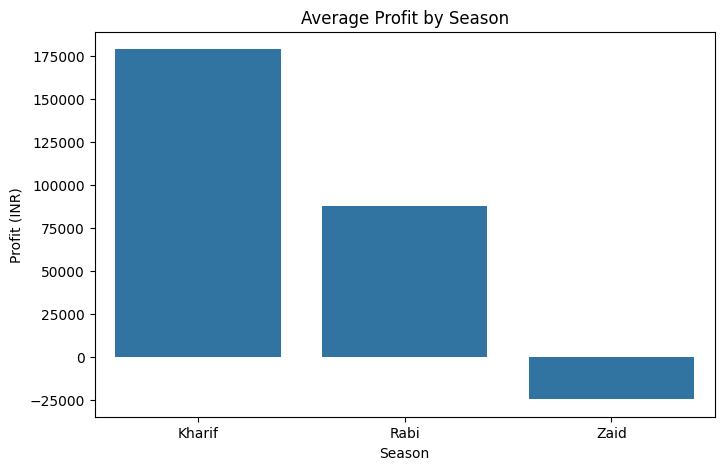

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.show()

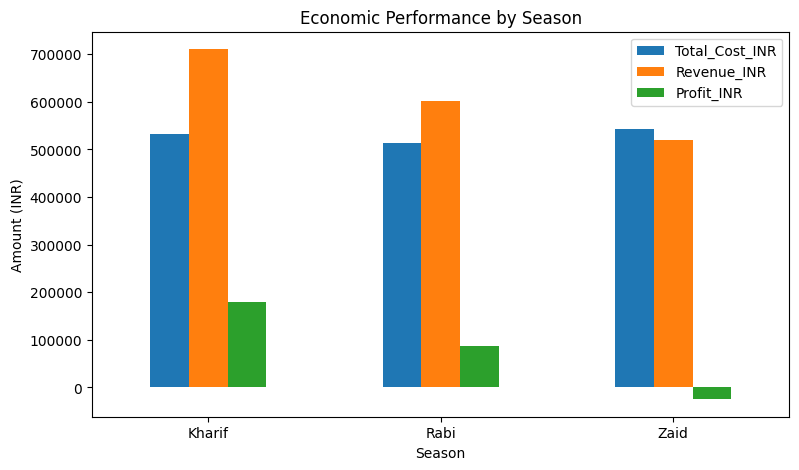

In [ ]:
economic = df.groupby("Season")[
    ["Total_Cost_INR", "Revenue_INR", "Profit_INR"]
].mean()

economic.plot(kind="bar", figsize=(9,5))

plt.title("Economic Performance by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=0)

plt.show()

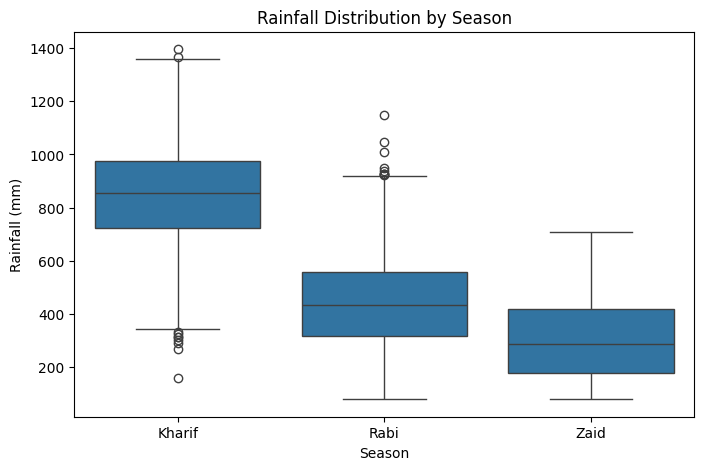

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Season",
    y="Rainfall_mm"
)

plt.title("Rainfall Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.show()

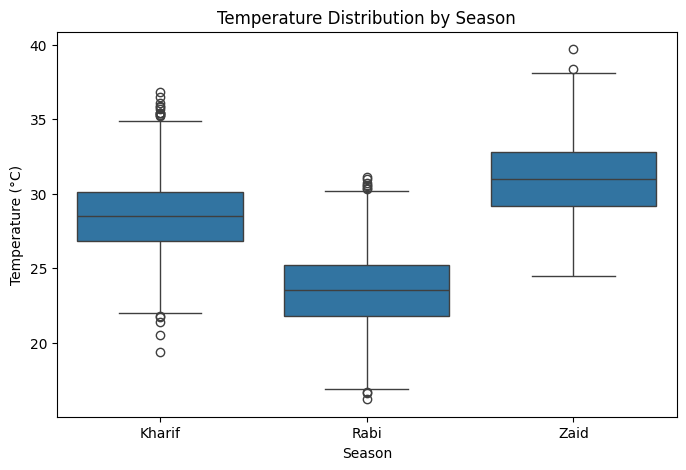

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Season",
    y="Avg_Temperature_C"
)

plt.title("Temperature Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")

plt.show()

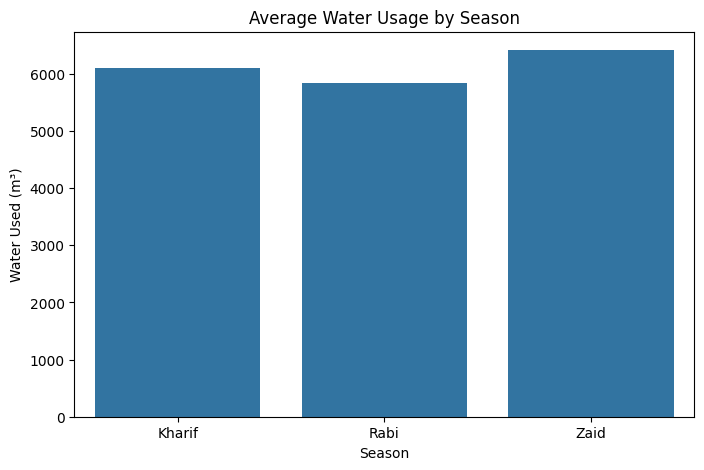

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Used_m3",
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.show()

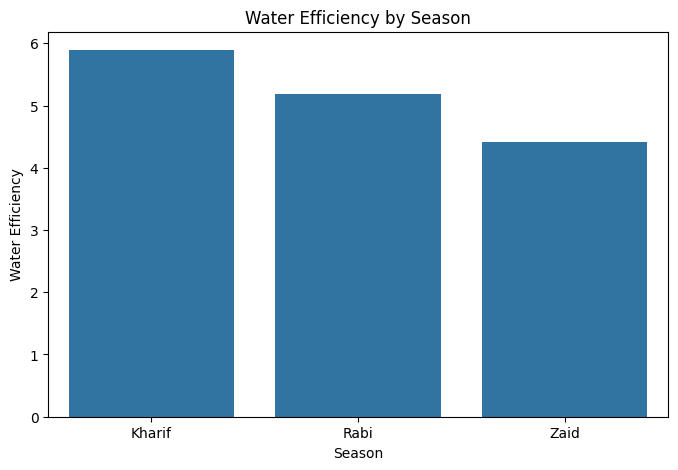

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Efficiency_t_per_1000m3",
    estimator=np.mean,
    errorbar=None
)

plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")

plt.show()

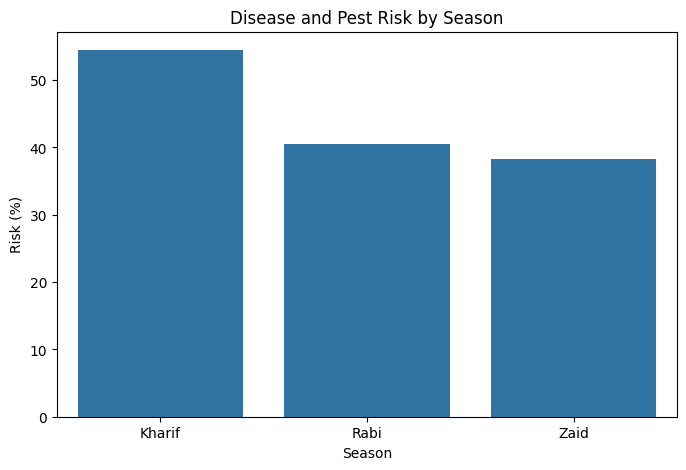

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Disease_Pest_Risk_pct",
    estimator=np.mean,
    errorbar=None
)

plt.title("Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")

plt.show()

In [ ]:
crop_summary = df.groupby("Crop").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean"
}).round(2)

display(
    crop_summary.sort_values(
        "Yield_Tonnes_Ha",
        ascending=False
    )
)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Crop,,,,
Sugarcane,46.64,392.41,1371980.11,817187.99
Maize,2.71,21.78,457067.99,-83978.33
Rice,2.43,19.29,423615.26,-102213.50
Wheat,2.11,16.85,400104.89,-123398.34
Chilli,1.54,12.38,1276777.23,750878.34
Groundnut,1.32,9.66,542935.50,44858.12
Cotton,1.23,9.40,639423.08,124546.92
Pulses,0.92,7.40,528465.87,-4238.05


In [ ]:
crop_season = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

display(crop_season.round(2))

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


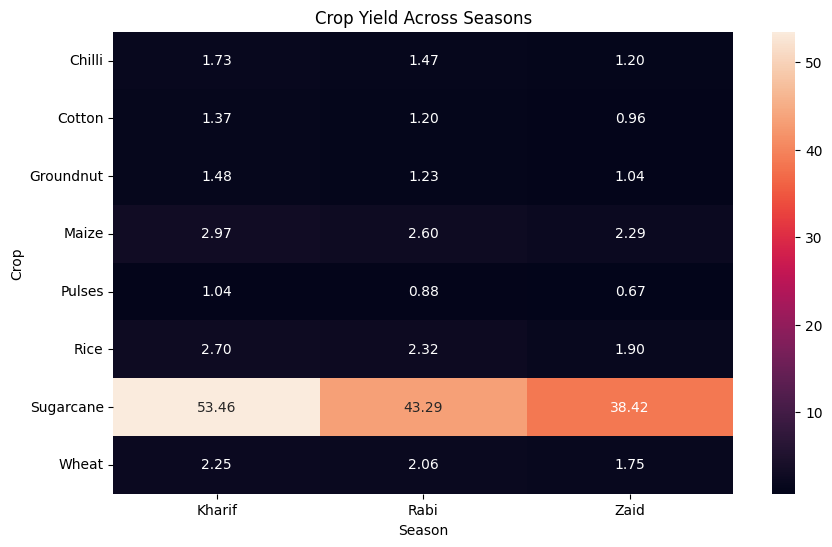

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    crop_season,
    annot=True,
    fmt=".2f"
)

plt.title("Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.show()

In [ ]:
irrigation = df.groupby("Irrigation_Method").agg({
    "Yield_Tonnes_Ha": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Profit_INR": "mean"
}).round(2)

display(irrigation)

,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Drip,6.58,5918.75,6.27,219626.00
Flood,4.86,8026.47,3.44,73354.02
Rainfed,4.60,3549.55,7.56,79050.37
Sprinkler,5.16,6208.26,4.67,91121.08


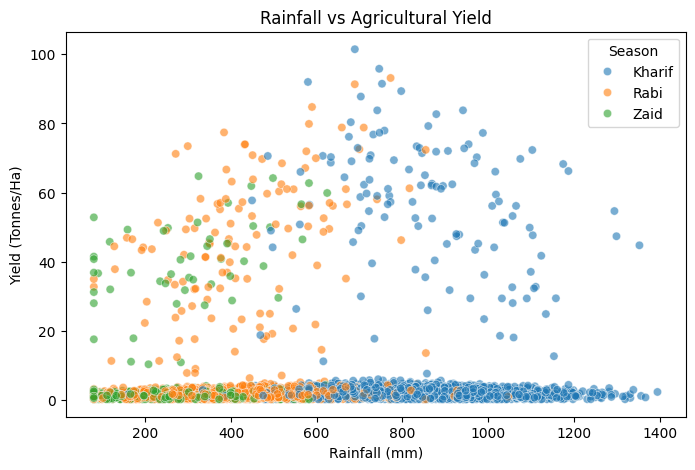

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6
)

plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

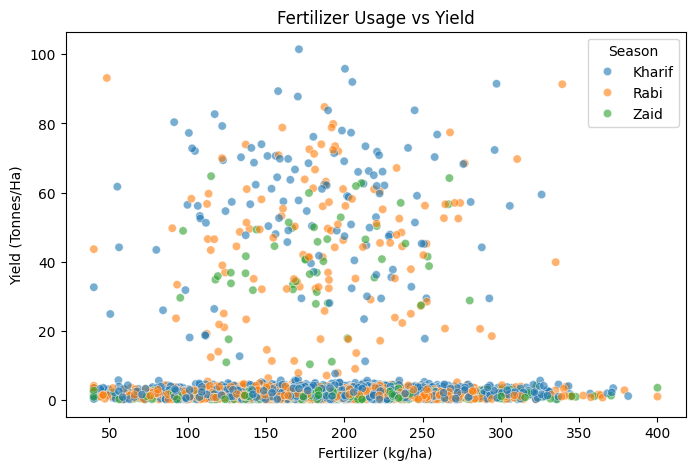

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6
)

plt.title("Fertilizer Usage vs Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

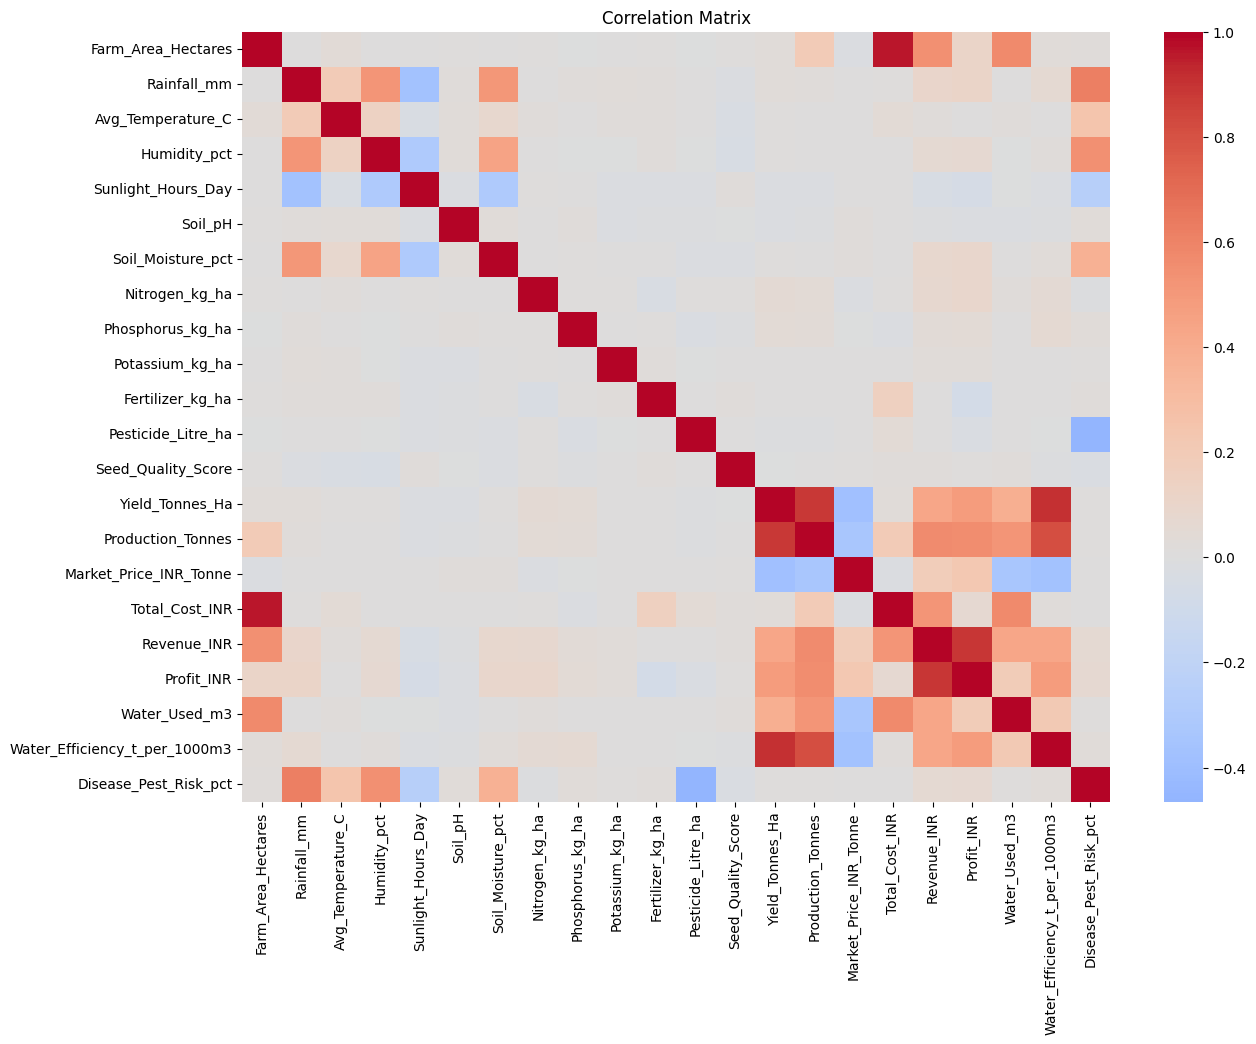

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
yield_corr = correlation["Yield_Tonnes_Ha"].sort_values(
    ascending=False
)

display(
    yield_corr.to_frame(
        "Correlation with Yield"
    )
)

,Correlation with Yield
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


In [ ]:
groups = [
    group["Yield_Tonnes_Ha"].values
    for name, group in df.groupby("Season")
]

anova = stats.f_oneway(*groups)

print("ANOVA Test: Season vs Yield")
print("--------------------------------")
print("F-statistic:", round(anova.statistic, 4))
print("P-value:", round(anova.pvalue, 6))

if anova.pvalue < 0.05:
    print("\nConclusion:")
    print("There is a statistically significant difference")
    print("in agricultural yield between seasons.")
else:
    print("\nConclusion:")
    print("No statistically significant difference was detected.")

ANOVA Test: Season vs Yield
--------------------------------
F-statistic: 1.5439
P-value: 0.213678

Conclusion:
No statistically significant difference was detected.


In [ ]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()
season_profit = df.groupby("Season")["Profit_INR"].mean()
crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean()

print("=" * 60)
print("KEY PROJECT FINDINGS")
print("=" * 60)

print("\nSEASON:")
print("Best yield season:", season_yield.idxmax())
print("Lowest yield season:", season_yield.idxmin())

print(
    "Highest average yield:",
    round(season_yield.max(), 2),
    "Tonnes/Ha"
)

print("\nECONOMIC PERFORMANCE:")
print("Best profit season:", season_profit.idxmax())

print(
    "Highest average profit: ₹",
    round(season_profit.max(), 2)
)

print("\nCROP:")
print("Highest-yielding crop:", crop_yield.idxmax())

print(
    "Average yield:",
    round(crop_yield.max(), 2),
    "Tonnes/Ha"
)

KEY PROJECT FINDINGS

SEASON:
Best yield season: Kharif
Lowest yield season: Zaid
Highest average yield: 5.63 Tonnes/Ha

ECONOMIC PERFORMANCE:
Best profit season: Kharif
Highest average profit: ₹ 178914.65

CROP:
Highest-yielding crop: Sugarcane
Average yield: 46.64 Tonnes/Ha


In [ ]:
best_season = season_yield.idxmax()
lowest_season = season_yield.idxmin()

best_crop = crop_yield.idxmax()
best_profit_season = season_profit.idxmax()

print("=" * 70)
print("FINAL CONCLUSION")
print("=" * 70)

print(f"""
The Seasonal Agriculture Performance Analysis examined agricultural
activities across different seasons, crops, environmental conditions,
resource usage and economic outcomes.

The analysis shows that {best_season} has the highest average
agricultural yield, while {lowest_season} has the lowest average yield.

The crop with the highest average yield is {best_crop}.

From an economic perspective, {best_profit_season} shows the
highest average profit.

The analysis also examined rainfall, temperature, water usage,
irrigation, fertilizer usage and disease/pest risk to understand
their relationships with agricultural performance.

RECOMMENDATIONS
----------------
1. Give greater attention to high-performing seasons.
2. Select crops based on their seasonal performance.
3. Monitor rainfall and soil conditions before planning cultivation.
4. Use efficient irrigation methods to reduce unnecessary water usage.
5. Optimize fertilizer usage according to crop and soil conditions.
6. Monitor disease and pest risk during vulnerable seasons.
7. Use historical seasonal data to support agricultural planning.
8. Continue collecting reliable data for better future analysis.
""")

FINAL CONCLUSION

The Seasonal Agriculture Performance Analysis examined agricultural
activities across different seasons, crops, environmental conditions,
resource usage and economic outcomes.

The analysis shows that Kharif has the highest average
agricultural yield, while Zaid has the lowest average yield.

The crop with the highest average yield is Sugarcane.

From an economic perspective, Kharif shows the
highest average profit.

The analysis also examined rainfall, temperature, water usage,
irrigation, fertilizer usage and disease/pest risk to understand
their relationships with agricultural performance.

RECOMMENDATIONS
----------------
1. Give greater attention to high-performing seasons.
2. Select crops based on their seasonal performance.
3. Monitor rainfall and soil conditions before planning cultivation.
4. Use efficient irrigation methods to reduce unnecessary water usage.
5. Optimize fertilizer usage according to crop and soil conditions.
6. Monitor disease and pest risk 